# 02 — Economics & Winning Strategy (what actually moves the score)
This challenge is scored on **portfolio profitability, cohort-timing shape, interval
calibration, counterfactual accuracy, and a regulator writeup** — *not* AUC. This
notebook explores the highest-leverage business reframes, per the hackathon-winner
playbook (business relevance > algorithm complexity; reframe hard problems into
simple robust ones).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
from src import data, economics as ec
from src.config import set_seeds, PRODUCT
set_seeds(); pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
tr = data.load_train(); lab = tr[data.labeled_mask(tr)].copy()
print("labeled loans:", len(lab))

labeled loans: 51722


## A. Loan economics — the profit-optimal decision threshold
Approve iff **E[profit] > 0**, i.e. **PD < break-even**. The break-even PD depends
entirely on the LGD assumption (do pre-default daily ACH draws count as cash collected?).

In [2]:
display(pd.Series(ec.summary(lab)))
print("revenue if fully repaid = {:.2%} of principal (3% fee + {:.2%} interest/60d)".format(ec.REV_RATE, ec.INT_TERM))

rev_rate                                                  0.0875
mean_revenue_if_full                                  2,076.7029
draws_aware               {'lgd': 0.322, 'break_even_pd': 0.214}
conservative              {'lgd': 0.909, 'break_even_pd': 0.088}
portfolio_default_rate                                    0.1740
dtype: object

revenue if fully repaid = 8.75% of principal (3% fee + 5.75% interest/60d)


**The whole policy hinges on LGD.** Defaulters pay ~59% of the schedule before
defaulting (default at day ~36 of 60). If credited → LGD≈0.32, approve PD<0.21.
If only post-hoc recovery counts (recovery rate ≈9%) → LGD≈0.91, approve PD<0.09.

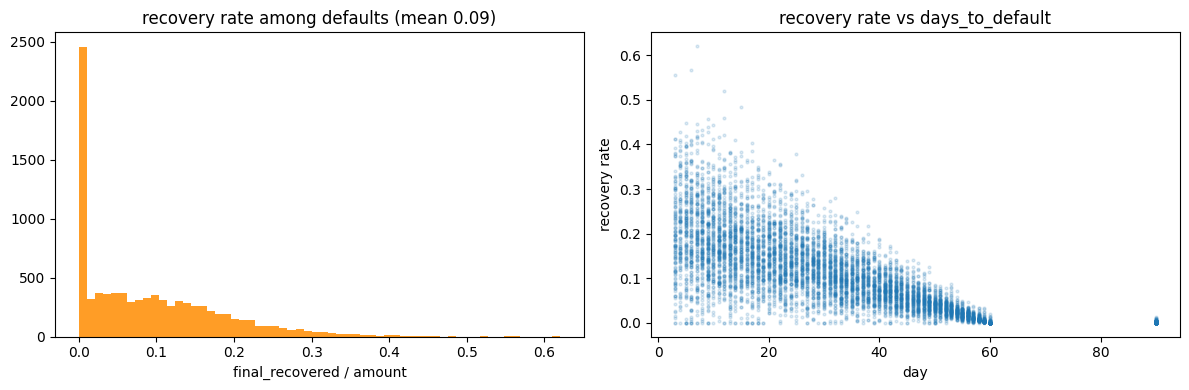

In [3]:
defm = lab["default_flag"]==1
rec_rate = (lab.loc[defm,"final_recovered_amount"].fillna(0)/lab.loc[defm,"requested_amount"])
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].hist(rec_rate, bins=60, color="darkorange", alpha=.85)
ax[0].set_title(f"recovery rate among defaults (mean {rec_rate.mean():.2f})"); ax[0].set_xlabel("final_recovered / amount")
# recovery vs days_to_default — do later defaults recover more (more draws collected)?
ax[1].scatter(lab.loc[defm,"days_to_default"], rec_rate, s=4, alpha=.15)
ax[1].set_title("recovery rate vs days_to_default"); ax[1].set_xlabel("day"); ax[1].set_ylabel("recovery rate")
plt.tight_layout(); plt.show()

### Profit frontier — how much profit is on the table, and at what threshold?
Oracle curve (threshold on the *true* outcome) shows the achievable profit ceiling and
how sensitive total profit is to the approval threshold, under each LGD assumption.

draws_aware : LGD=0.32  break-even PD=0.214  oracle-max profit=\$86.6M at approve_rate=0.83


conservative: LGD=0.91  break-even PD=0.088  oracle-max profit=\$86.6M at approve_rate=0.83


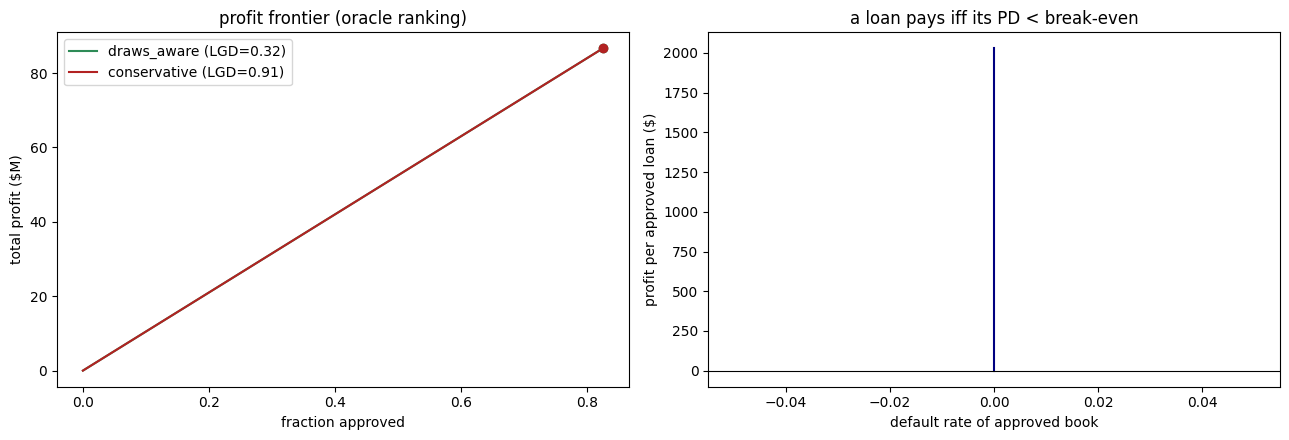

In [4]:
amt = lab["requested_amount"].to_numpy(); y = lab["default_flag"].to_numpy()
fig, ax = plt.subplots(1,2, figsize=(13,4.5))
for mode,color in [("draws_aware","seagreen"),("conservative","firebrick")]:
    lgd = ec.lgd_components(lab, mode).mean()
    pc = ec.profit_curve(y, amt, pd_hat=y, lgd=lgd)   # oracle: approve true-good first
    best = pc.loc[pc["total_profit"].idxmax()]
    ax[0].plot(pc["approve_rate"], pc["total_profit"]/1e6, label=f"{mode} (LGD={lgd:.2f})", color=color)
    ax[0].scatter([best["approve_rate"]],[best["total_profit"]/1e6], color=color, zorder=5)
    print(f"{mode:12s}: LGD={lgd:.2f}  break-even PD={ec.break_even_pd(lgd):.3f}  "
          f"oracle-max profit=\${best['total_profit']/1e6:.1f}M at approve_rate={best['approve_rate']:.2f}")
ax[0].set_xlabel("fraction approved"); ax[0].set_ylabel("total profit (\$M)")
ax[0].set_title("profit frontier (oracle ranking)"); ax[0].legend()
# profit-per-approved vs realized default rate of the approved book
lgd=ec.lgd_components(lab,'draws_aware').mean()
pc=ec.profit_curve(y,amt,pd_hat=y,lgd=lgd)
ax[1].plot(pc["default_rate_approved"], pc["profit_per_approved"], color="navy")
ax[1].axhline(0,c="k",lw=.8); ax[1].set_xlabel("default rate of approved book"); ax[1].set_ylabel("profit per approved loan (\$)")
ax[1].set_title("a loan pays iff its PD < break-even"); plt.tight_layout(); plt.show()

## B. Reframe Deliverable B: fixed *shape* × per-cohort *level*
Hackathon move: convert the 13×13 time-series into one robust regression. If the
*normalized* cumulative-default shape is invariant across cohorts/segments, then
B ≈ canonical_shape(week) × cohort_level — fit only the level, reuse the shape.

canonical normalized shape (fraction of final defaults realized by week):


day,1,2,3,4,5,6,7,8,9,10,11,12,13
frac_of_final,0.0720,0.1900,0.2890,0.3880,0.4850,0.5710,0.6520,0.7350,0.7750,0.7750,0.7750,0.7750,1.0000


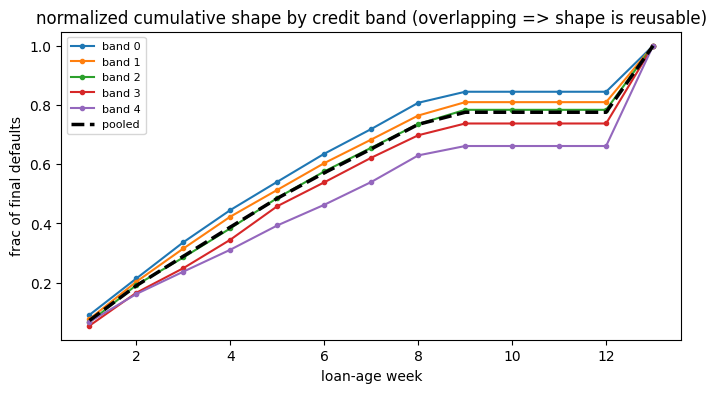

In [5]:
from src import eda
H = eda.discrete_hazard(tr)
wk = np.ceil(H["day"]/7).astype(int).clip(upper=13)
shape = H.groupby(wk)["cum_default_frac"].max(); shape = shape/shape.iloc[-1]  # normalized to 1.0 at wk13
print("canonical normalized shape (fraction of final defaults realized by week):")
display(shape.round(3).to_frame("frac_of_final").T)

# is the shape stable across credit bands? (proxy for cohort stability, which train lacks)
fig, ax = plt.subplots(figsize=(8,4))
for band, g in tr[data.labeled_mask(tr)].groupby("owner_personal_credit_band"):
    h = eda.discrete_hazard(g); w = np.ceil(h["day"]/7).astype(int).clip(upper=13)
    s = h.groupby(w)["cum_default_frac"].max(); s = s/s.iloc[-1]
    ax.plot(s.index, s.values, marker=".", label=f"band {band}")
ax.plot(shape.index, shape.values, "k--", lw=2.5, label="pooled")
ax.set_title("normalized cumulative shape by credit band (overlapping => shape is reusable)")
ax.set_xlabel("loan-age week"); ax.set_ylabel("frac of final defaults"); ax.legend(fontsize=8); plt.show()

## C. Quick calibration baseline (calibration is separately scored — cheap points)
A fast GroupKFold LGBM to see how far off raw scores are, so we know how much
isotonic/conformal work Deliverable A's intervals need.

OOF AUC=0.7702  Brier=0.1179  base rate=0.174


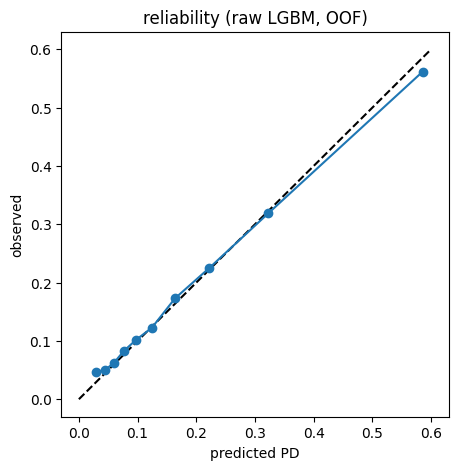

,pred,obs,n
"(0.0051, 0.0381]",0.0290,0.0460,5173
"(0.0381, 0.0524]",0.0450,0.0510,5172
"(0.0524, 0.0676]",0.0600,0.0620,5172
"(0.0676, 0.0857]",0.0760,0.0830,5172
"(0.0857, 0.109]",0.0970,0.1010,5172
"(0.109, 0.142]",0.1240,0.1230,5172
"(0.142, 0.189]",0.1640,0.1730,5172
"(0.189, 0.262]",0.2220,0.2250,5172
"(0.262, 0.402]",0.3230,0.3190,5172
"(0.402, 0.993]",0.5860,0.5620,5173


In [6]:
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, brier_score_loss
feats = [c for c in data.numeric_feature_columns(tr) if c not in ("prior_approved_amount",)]
X = lab[feats].fillna(lab[feats].median()); y = lab["default_flag"].astype(int).to_numpy()
groups = lab["business_id"]; oof = np.zeros(len(lab))
for trn,val in GroupKFold(5).split(X,y,groups):
    m = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                           subsample=.8, colsample_bytree=.8, random_state=20260605, verbose=-1)
    m.fit(X.iloc[trn], y[trn])
    oof[val] = m.predict_proba(X.iloc[val])[:,1]
print(f"OOF AUC={roc_auc_score(y,oof):.4f}  Brier={brier_score_loss(y,oof):.4f}  base rate={y.mean():.3f}")
# reliability curve
bins = pd.qcut(oof, 10, duplicates="drop")
rel = pd.DataFrame({"pred":oof,"y":y}).groupby(bins).agg(pred=("pred","mean"), obs=("y","mean"), n=("y","size"))
fig,ax=plt.subplots(figsize=(5,5)); ax.plot([0,.6],[0,.6],"k--")
ax.plot(rel["pred"], rel["obs"], marker="o"); ax.set_xlabel("predicted PD"); ax.set_ylabel("observed")
ax.set_title("reliability (raw LGBM, OOF)"); plt.show(); display(rel.round(3))

---
### Takeaways (logged to reports/writeup_notes.md)
1. **A's biggest lever is the break-even PD, not the classifier.** Pin the LGD/scoring
   assumption; make the policy robust across LGD∈[0.32,0.91] (PD*∈[0.09,0.21]).
2. **B = shape × level.** If shapes overlap, fit only 13 cohort levels + reuse the
   canonical 13-week shape; bootstrap loans-within-cohort for intervals.
3. **Calibration is cheap, separately-scored points** — isotonic + conformal on val.
4. **Skip RAPIDS/GPU** — 85k×44 trains in <1s on CPU; spend effort on economics,
   calibration, and the causal writeup, not throughput.